# Chapitre 5 — Transformer et restructurer les données

**Cours : Analyse et traitement des données** · Auteur : *Issa Gueye*

## Objectifs

- Agréger avec **`groupby`** (split–apply–combine) : `agg`, `transform`, `filter`.
- Combiner des tables : **`merge`** (jointures) et **`concat`**.
- Restructurer : **`pivot_table`**, **`melt`**, **`crosstab`** (format large ↔ long).
- Travailler avec des **séries temporelles** : `resample`, `rolling`, décalages.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = next(p for p in [Path("data/brutes"), Path("../data/brutes"), Path("../../data/brutes")] if p.exists())
PROPRES = DATA.parent / "propres" / "ventes_propres.parquet"
if not PROPRES.exists():  # le chapitre 4 produit ce fichier ; sinon on le reconstruit
    import sys; sys.path.insert(0, str(DATA.parents[1] / "src"))
    from atd.nettoyage import nettoyer_ventes
    PROPRES.parent.mkdir(exist_ok=True)
    nettoyer_ventes(pd.read_csv(DATA / "ventes_boutiques.csv"),
                    pd.read_csv(DATA / "regions_senegal.csv")["region"])[0].to_parquet(PROPRES)
ventes = pd.read_parquet(PROPRES)
ventes.head(3)

,id_transaction,date,region,boutique,produit,categorie,prix_unitaire,quantite,mode_paiement,quantite_imputee,montant
0,T100117,2025-01-01,Saint-Louis,BTQ-SAI-03,Cahier 200p,Fournitures,500.0,3,Orange Money,False,1500.0
1,T102368,2025-01-01,Louga,BTQ-LOU-02,Crédit téléphone,Services,1020.0,3,Orange Money,False,3060.0
2,T103823,2025-01-01,Ziguinchor,BTQ-ZIG-04,Recharge Woyofal,Services,4730.0,3,Orange Money,False,14190.0


## 1. `groupby` : diviser — appliquer — combiner

```text
  données ──split──► groupe Dakar ──apply(sum)──► 1 valeur ─┐
                └──► groupe Thiès ──apply(sum)──► 1 valeur ─┼─combine─► résultat
                └──► …                                       ┘
```

In [2]:
ca_region = ventes.groupby("region", observed=True)["montant"].sum().sort_values(ascending=False)
ca_region.map("{:,.0f}".format)

region
Dakar          12,068,950
Thiès           5,601,060
Diourbel        5,535,170
Kaolack         4,341,250
Saint-Louis     4,148,580
Louga           3,123,130
Ziguinchor      2,880,790
Tambacounda     2,704,120
Name: montant, dtype: str

### Plusieurs statistiques, plusieurs colonnes : `agg` avec agrégations nommées

In [3]:
synthese = ventes.groupby("region", observed=True).agg(
    n_transactions=("id_transaction", "count"),
    ca_total=("montant", "sum"),
    panier_moyen=("montant", "mean"),
    panier_median=("montant", "median"),
    n_boutiques=("boutique", "nunique"),
).sort_values("ca_total", ascending=False)
synthese.round(0)

,n_transactions,ca_total,panier_moyen,panier_median,n_boutiques
region,,,,,
Dakar,1488,12068950.0,8111.0,3095.0,5
Thiès,679,5601060.0,8249.0,3400.0,5
Diourbel,660,5535170.0,8387.0,3000.0,5
Kaolack,491,4341250.0,8842.0,3270.0,5
Saint-Louis,510,4148580.0,8134.0,3060.0,5
Louga,406,3123130.0,7692.0,3570.0,5
Ziguinchor,405,2880790.0,7113.0,3030.0,5
Tambacounda,361,2704120.0,7491.0,2970.0,5


### `transform` : renvoie un résultat **de même taille** que l'entrée
Idéal pour comparer chaque ligne à son groupe.

In [4]:
ventes["part_ca_region"] = ventes["montant"] / ventes.groupby("region", observed=True)["montant"].transform("sum")
ventes["ecart_prix_moyen_produit"] = ventes["prix_unitaire"] - ventes.groupby("produit")["prix_unitaire"].transform("mean")
ventes[["region", "produit", "montant", "part_ca_region", "ecart_prix_moyen_produit"]].head()

,region,produit,montant,part_ca_region,ecart_prix_moyen_produit
0,Saint-Louis,Cahier 200p,1500.0,0.000362,-2.372093
1,Louga,Crédit téléphone,3060.0,0.000980,22.647815
2,Ziguinchor,Recharge Woyofal,14190.0,0.004926,-257.000000
3,Dakar,Huile 5L,12840.0,0.001064,-102.933985
4,Diourbel,Lait en poudre 400g,4640.0,0.000838,23.574879


### `filter` : garder des **groupes entiers** selon une condition

In [5]:
gros_produits = ventes.groupby("produit").filter(lambda g: g["montant"].sum() > 10_000_000)
print(gros_produits["produit"].unique())

<ArrowStringArray>
['Riz brisé 25kg']
Length: 1, dtype: str


### Regrouper sur plusieurs clés

In [6]:
ventes.groupby(["region", "mode_paiement"], observed=True)["montant"].sum().unstack().round(-3).head()

mode_paiement,Carte,Espèces,Inconnu,Orange Money,Wave
region,,,,,
Dakar,609000.0,5040000.0,482000.0,2463000.0,3476000.0
Diourbel,270000.0,2469000.0,292000.0,951000.0,1553000.0
Kaolack,292000.0,2037000.0,86000.0,899000.0,1028000.0
Louga,92000.0,1508000.0,257000.0,501000.0,765000.0
Saint-Louis,193000.0,1846000.0,263000.0,752000.0,1094000.0


## 2. Tableaux croisés : `pivot_table` et `crosstab`

In [7]:
pd.pivot_table(ventes, values="montant", index="categorie", columns="mode_paiement",
               aggfunc="sum", margins=True, margins_name="Total", observed=True).round(-3)

mode_paiement,Carte,Espèces,Inconnu,Orange Money,Wave,Total
categorie,,,,,,
Alimentaire,1401000.0,12430000.0,1333000.0,5281000.0,7653000.0,28098000.0
Fournitures,124000.0,1099000.0,133000.0,470000.0,711000.0,2536000.0
Hygiène,92000.0,820000.0,173000.0,404000.0,584000.0,2073000.0
Services,355000.0,3316000.0,423000.0,1504000.0,2097000.0,7695000.0
Total,1972000.0,17664000.0,2062000.0,7659000.0,11046000.0,40403000.0


In [8]:
# Répartition (en %) des modes de paiement par région — chaque ligne somme à 100
pd.crosstab(ventes["region"], ventes["mode_paiement"], normalize="index").mul(100).round(1)

mode_paiement,Carte,Espèces,Inconnu,Orange Money,Wave
region,,,,,
Dakar,4.8,44.0,5.4,19.0,26.7
Diourbel,4.7,43.6,6.1,19.1,26.5
Kaolack,5.3,41.3,6.3,22.0,25.1
Louga,2.7,44.1,7.4,16.5,29.3
Saint-Louis,4.7,42.0,6.5,19.4,27.5
Tambacounda,3.6,41.3,7.2,15.5,32.4
Thiès,3.8,40.2,6.0,19.6,30.3
Ziguinchor,3.7,42.0,6.4,20.0,27.9


## 3. Format large ↔ format long

- **Long (tidy)** : une ligne par (unité, variable, valeur) — requis par `seaborn`, `groupby`, les modèles.
- **Large** : une colonne par modalité — pratique pour la lecture humaine et les tableaux.

In [9]:
large = (ventes.assign(mois=ventes["date"].dt.month)
         .pivot_table(index="region", columns="mois", values="montant", aggfunc="sum", observed=True)
         .round(-3))
large.iloc[:3, :6]

mois,1,2,3,4,5,6
region,,,,,,
Dakar,1255000.0,946000.0,915000.0,887000.0,1268000.0,1032000.0
Diourbel,409000.0,272000.0,540000.0,368000.0,462000.0,566000.0
Kaolack,239000.0,385000.0,640000.0,483000.0,300000.0,386000.0


In [10]:
long = large.reset_index().melt(id_vars="region", var_name="mois", value_name="ca")
long.head()

,region,mois,ca
0,Dakar,1,1255000.0
1,Diourbel,1,409000.0
2,Kaolack,1,239000.0
3,Louga,1,313000.0
4,Saint-Louis,1,490000.0


`pivot` (sans agrégation) est l'inverse exact de `melt` ; `pivot_table` agrège si plusieurs lignes tombent dans la même case.

## 4. Combiner des tables

### 4.1 Jointures avec `merge`

| `how=` | Garde… | Analogue SQL |
|---|---|---|
| `"inner"` | les clés présentes **dans les deux** tables | `INNER JOIN` |
| `"left"` | **toutes** les lignes de gauche | `LEFT JOIN` |
| `"right"` | toutes les lignes de droite | `RIGHT JOIN` |
| `"outer"` | toutes les clés des deux | `FULL OUTER JOIN` |

In [11]:
regions = pd.read_csv(DATA / "regions_senegal.csv")
par_region = synthese.reset_index()
par_region["region"] = par_region["region"].astype(str)

jointure = par_region.merge(regions, on="region", how="left", validate="one_to_one", indicator=True)
print(jointure["_merge"].value_counts())
jointure[["region", "zone", "superficie_km2", "ca_total"]].head()

_merge
both          8
left_only     0
right_only    0
Name: count, dtype: int64


,region,zone,superficie_km2,ca_total
0,Dakar,Ouest,547,12068950.0
1,Thiès,Ouest,6601,5601060.0
2,Diourbel,Centre,4824,5535170.0
3,Kaolack,Centre,5357,4341250.0
4,Saint-Louis,Nord,19241,4148580.0


> ✅ **Bonnes pratiques de jointure**
> - `validate="one_to_one"` / `"many_to_one"` : lève une erreur si la clé n'est pas unique là où elle doit l'être
>   (évite la **multiplication silencieuse des lignes**).
> - `indicator=True` : colonne `_merge` qui dit d'où vient chaque ligne → repérer les clés orphelines.
> - Vérifier le **nombre de lignes** avant/après.

In [12]:
orphelines = regions.merge(par_region, on="region", how="left", indicator=True).query("_merge == 'left_only'")
print("Régions sans aucune vente dans nos données :", orphelines["region"].tolist())

Régions sans aucune vente dans nos données : ['Fatick', 'Kolda', 'Matam', 'Kaffrine', 'Kédougou', 'Sédhiou']


### 4.2 Empiler avec `concat`

In [13]:
t1 = ventes[ventes["date"].dt.quarter == 1]
t2 = ventes[ventes["date"].dt.quarter == 2]
s1 = pd.concat([t1, t2], ignore_index=True)                       # l'un sous l'autre (mêmes colonnes)
print(len(t1), "+", len(t2), "=", len(s1))
cote_a_cote = pd.concat([ca_region.rename("CA"), synthese["n_boutiques"]], axis=1)   # côte à côte (alignement sur l'index)
cote_a_cote.head(3)

1216 + 1269 = 2485


,CA,n_boutiques
region,,
Dakar,12068950.0,5
Thiès,5601060.0,5
Diourbel,5535170.0,5


## 5. Séries temporelles

### 5.1 Ré-échantillonner : `resample`

In [14]:
serie = ventes.set_index("date")["montant"]
mensuel = serie.resample("ME").sum()        # "ME" = fin de mois ; "W" = semaine ; "QE" = trimestre
hebdo = serie.resample("W").sum()
mensuel.map("{:,.0f}".format).head()

date
2025-01-31    3,860,500
2025-02-28    2,854,450
2025-03-31    3,365,920
2025-04-30    3,265,760
2025-05-31    3,788,950
Freq: ME, Name: montant, dtype: str

### 5.2 Fenêtres glissantes : `rolling` (lissage)

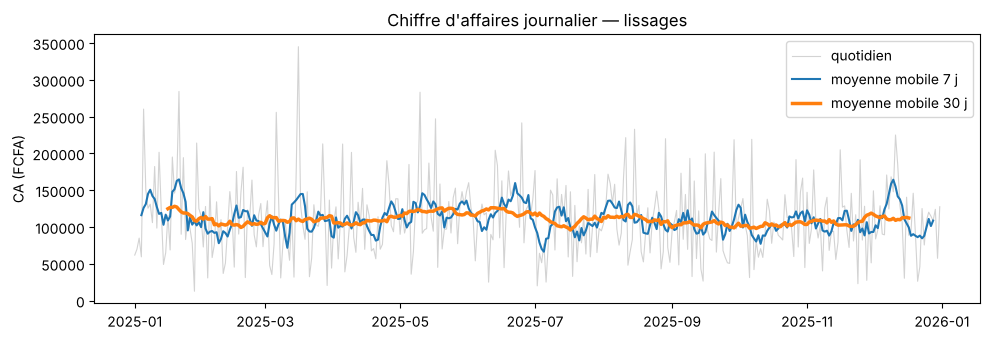

In [15]:
quotidien = serie.resample("D").sum()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(quotidien, color="lightgray", lw=0.8, label="quotidien")
ax.plot(quotidien.rolling(7, center=True).mean(), lw=1.5, label="moyenne mobile 7 j")
ax.plot(quotidien.rolling(30, center=True).mean(), lw=2.5, label="moyenne mobile 30 j")
ax.set_ylabel("CA (FCFA)"); ax.legend(); ax.set_title("Chiffre d'affaires journalier — lissages")
plt.tight_layout(); plt.show()

### 5.3 Décalages et variations : `shift`, `diff`, `pct_change`

In [16]:
m = mensuel.to_frame("ca")
m["ca_mois_prec"] = m["ca"].shift(1)
m["variation"] = m["ca"].diff()
m["variation_pct"] = m["ca"].pct_change().mul(100).round(1)
m["ca_cumule"] = m["ca"].cumsum()
m.head(4)

,ca,ca_mois_prec,variation,variation_pct,ca_cumule
date,,,,,
2025-01-31,3860500.0,NaN,NaN,NaN,3860500.0
2025-02-28,2854450.0,3860500.0,-1006050.0,-26.1,6714950.0
2025-03-31,3365920.0,2854450.0,511470.0,17.9,10080870.0
2025-04-30,3265760.0,3365920.0,-100160.0,-3.0,13346630.0


### 5.4 Saisonnalité : la météo de Dakar

In [17]:
meteo = pd.read_csv(DATA / "meteo_dakar.csv", parse_dates=["date"]).set_index("date").asfreq("D")
meteo.loc[meteo["temp_moy_c"] < -50, "temp_moy_c"] = np.nan
meteo["mois"] = meteo.index.month
profil_mensuel = meteo.groupby("mois").agg(temp=("temp_moy_c", "mean"), pluie=("precip_mm", "sum"))
profil_mensuel["pluie"] /= meteo.index.year.nunique()     # cumul moyen par an
profil_mensuel.round(1).T

mois,1,2,3,4,5,6,7,8,9,10,11,12
temp,23.4,22.4,22.1,22.8,24.1,25.9,27.6,28.9,29.0,28.4,26.8,25.2
pluie,0.1,4.1,0.2,0.0,25.2,2.5,117.2,142.1,142.6,102.5,1.6,5.6


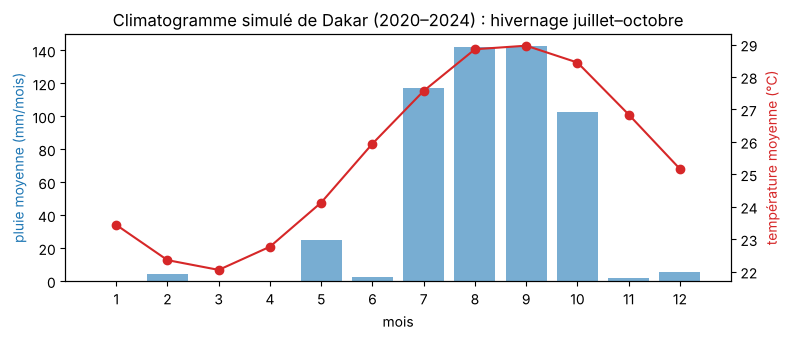

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 3.5))
ax1.bar(profil_mensuel.index, profil_mensuel["pluie"], color="tab:blue", alpha=0.6)
ax1.set_ylabel("pluie moyenne (mm/mois)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(profil_mensuel.index, profil_mensuel["temp"], color="tab:red", marker="o")
ax2.set_ylabel("température moyenne (°C)", color="tab:red")
ax1.set_xticks(range(1, 13)); ax1.set_xlabel("mois")
ax1.set_title("Climatogramme simulé de Dakar (2020–2024) : hivernage juillet–octobre")
plt.tight_layout(); plt.show()

## 6. Fonctions personnalisées : `apply`, `map` — et pourquoi les éviter quand c'est possible

`apply` exécute une fonction Python **ligne par ligne** : flexible mais lent.
Préférer les opérations **vectorisées** (`np.where`, `np.select`, `pd.cut`, méthodes `.str`, `.dt`).

In [19]:
conditions = [ventes["montant"] < 2_000, ventes["montant"] < 20_000]
ventes["taille_panier"] = np.select(conditions, ["petit", "moyen"], default="grand")
ventes["tranche"] = pd.cut(ventes["montant"], bins=[0, 2_000, 20_000, np.inf],
                           labels=["< 2k", "2k–20k", "> 20k"], right=False)
ventes[["montant", "taille_panier", "tranche"]].sample(5, random_state=0)

,montant,taille_panier,tranche
398,32100.0,grand,> 20k
3833,77100.0,grand,> 20k
4836,2400.0,moyen,2k–20k
4572,25780.0,grand,> 20k
636,66000.0,grand,> 20k


## À retenir

| Besoin | Outil |
|---|---|
| Résumer par groupe | `groupby(...).agg(nom=(col, fonction))` |
| Comparer une ligne à son groupe | `groupby(...).transform(...)` |
| Tableau croisé | `pivot_table`, `crosstab(normalize=...)` |
| Large → long / long → large | `melt` / `pivot` |
| Joindre | `merge(how=..., validate=..., indicator=True)` |
| Empiler | `concat` |
| Séries temporelles | `resample`, `rolling`, `shift`, `diff`, `pct_change` |

➡️ **Chapitre suivant : analyse exploratoire et visualisation.**